# EDA 17: Age and Gender Customer Behavior

This notebook analyzes customer behavior by age group and gender, including purchase volume, revenue, AOV, order frequency, and return risk using `customers.csv`, `orders.csv`, `order_items.csv`, and `returns.csv`.

Demographic findings are exploratory signals for segmentation, marketing interpretation, and return-risk review. They should not be treated as causal claims.

## 1. Setup and file discovery

The notebook recursively locates the required CSV files from the current working directory and displays the discovery status. No EDA tables or charts are saved to files.

In [1]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

plt.style.use("default")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

ROOT = Path.cwd()
REQUIRED_FILES = ["customers.csv", "orders.csv", "order_items.csv", "returns.csv"]

def normalize_name(value):
    return re.sub(r"[^a-z0-9]+", "", str(value).strip().lower())

def display_warning(message):
    print(f"WARNING: {message}")

def find_csv_files(root, filenames):
    all_csvs = list(root.rglob("*.csv"))
    found = {}
    for filename in filenames:
        target = normalize_name(filename)
        matches = [p for p in all_csvs if normalize_name(p.name) == target]
        matches = sorted(matches, key=lambda p: (len(p.parts), str(p).lower()))
        found[filename] = matches[0] if matches else None
    return found

file_paths = find_csv_files(ROOT, REQUIRED_FILES)
discovery_table = pd.DataFrame(
    {
        "file": list(file_paths.keys()),
        "path": [str(p) if p is not None else None for p in file_paths.values()],
        "status": ["found" if p is not None else "missing" for p in file_paths.values()],
    }
)
display(discovery_table)

for name, path in file_paths.items():
    if path is None:
        display_warning(f"{name} was not found. Dependent analysis will continue where possible.")

,file,path,status
0,customers.csv,D:\Code\Datathon 2026\datathon-2026-round-1\cu...,found
1,orders.csv,D:\Code\Datathon 2026\datathon-2026-round-1\or...,found
2,order_items.csv,D:\Code\Datathon 2026\datathon-2026-round-1\or...,found
3,returns.csv,D:\Code\Datathon 2026\datathon-2026-round-1\re...,found


## 2. Load customers, orders, order_items, and returns

Available files are loaded safely with pandas. Initial column lists and samples are shown to make schema assumptions transparent.

In [2]:
def safe_read_csv(path):
    if path is None:
        return None
    attempts = [
        {"low_memory": False},
        {"encoding": "utf-8-sig", "low_memory": False},
        {"encoding": "latin1", "low_memory": False},
    ]
    last_error = None
    for kwargs in attempts:
        try:
            return pd.read_csv(path, **kwargs)
        except Exception as exc:
            last_error = exc
    display_warning(f"Could not load {path}: {last_error}")
    return None

data = {name: safe_read_csv(path) for name, path in file_paths.items()}
customers = data.get("customers.csv")
orders = data.get("orders.csv")
order_items = data.get("order_items.csv")
returns = data.get("returns.csv")

load_summary = []
for name, df in data.items():
    load_summary.append(
        {
            "file": name,
            "loaded": df is not None,
            "rows": 0 if df is None else len(df),
            "columns": 0 if df is None else df.shape[1],
        }
    )
display(pd.DataFrame(load_summary))

for name, df in data.items():
    if df is not None:
        print(f"\n{name} columns:")
        print(list(df.columns))
        display(df.head())

,file,loaded,rows,columns
0,customers.csv,True,121930,7
1,orders.csv,True,646945,8
2,order_items.csv,True,714669,7
3,returns.csv,True,39939,7



customers.csv columns:
['customer_id', 'zip', 'city', 'signup_date', 'gender', 'age_group', 'acquisition_channel']


,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search
3,4,15201,Hai Phong,2017-11-29,Male,35-44,referral
4,5,15201,Hai Phong,2022-09-23,Male,55+,organic_search



orders.csv columns:
['order_id', 'order_date', 'customer_id', 'zip', 'order_status', 'payment_method', 'device_type', 'order_source']


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign



order_items.csv columns:
['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount', 'promo_id', 'promo_id_2']


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,"1,138.2200",0.0000,NaN,NaN
1,2,609,7,"10,166.2500",0.0000,NaN,NaN
2,3,396,3,"11,220.3300",0.0000,NaN,NaN
3,4,635,5,"10,639.2500",0.0000,NaN,NaN
4,6,1935,1,"1,597.8400",0.0000,NaN,NaN



returns.csv columns:
['return_id', 'order_id', 'product_id', 'return_date', 'return_reason', 'return_quantity', 'refund_amount']


,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount
0,RET-000001,2,609,2012-07-25,late_delivery,6,"52,458.0100"
1,RET-000002,32,1862,2012-07-16,wrong_size,2,"5,141.3700"
2,RET-000003,35,2359,2012-07-16,wrong_size,1,"5,315.9500"
3,RET-000004,47,1449,2012-07-11,wrong_size,4,"6,493.7500"
4,RET-000005,47,1450,2012-07-25,wrong_size,1,"1,740.7600"


## 3. Identify customer, demographic, order, revenue, and return columns

Column detection handles common naming variations by scoring normalized names, checking date parse quality, and checking numeric plausibility. Missing fields produce warnings instead of stopping the notebook.

In [3]:
def score_column(col, include_terms=None, exclude_terms=None):
    n = normalize_name(col)
    include_terms = include_terms or []
    exclude_terms = exclude_terms or []
    score = 0
    for term, points in include_terms:
        if normalize_name(term) in n:
            score += points
    for term, points in exclude_terms:
        if normalize_name(term) in n:
            score -= points
    return score

def choose_column_by_terms(df, include_terms, exclude_terms=None, min_score=1):
    if df is None or df.empty:
        return None
    scored = []
    for col in df.columns:
        scored.append((score_column(col, include_terms, exclude_terms), col))
    scored = sorted(scored, key=lambda x: (x[0], -len(str(x[1]))), reverse=True)
    return scored[0][1] if scored and scored[0][0] >= min_score else None

def choose_numeric_column(df, include_terms, exclude_terms=None, min_score=1):
    if df is None or df.empty:
        return None
    scored = []
    for col in df.columns:
        numeric = pd.to_numeric(df[col], errors="coerce")
        valid_rate = numeric.notna().mean()
        if valid_rate < 0.5 or numeric.nunique(dropna=True) < 2:
            continue
        score = score_column(col, include_terms, exclude_terms) + valid_rate * 3
        scored.append((score, col))
    scored = sorted(scored, reverse=True)
    return scored[0][1] if scored and scored[0][0] >= min_score else None

def choose_date_column(df, preferred_terms=None):
    if df is None or df.empty:
        return None
    preferred_terms = preferred_terms or []
    candidates = []
    for col in df.columns:
        parsed = pd.to_datetime(df[col], errors="coerce")
        valid_rate = parsed.notna().mean()
        unique_count = parsed.nunique(dropna=True)
        name_score = score_column(
            col,
            preferred_terms + [("date", 10), ("time", 4), ("created", 5), ("signup", 6), ("birth", 6), ("order", 5), ("return", 5)],
            [("id", 8), ("zip", 8), ("price", 8), ("amount", 7), ("quantity", 7), ("qty", 7)],
        )
        if valid_rate >= 0.45 and unique_count >= 1:
            candidates.append((valid_rate * 100 + name_score + min(unique_count, 100) * 0.01, col))
    candidates = sorted(candidates, reverse=True)
    return candidates[0][1] if candidates else None

def choose_common_key(left_df, right_df, left_terms, right_terms=None):
    if left_df is None or right_df is None:
        return None, None
    right_terms = right_terms or left_terms
    left_candidates = [
        col for col in left_df.columns
        if score_column(col, left_terms, [("date", 5), ("amount", 5), ("price", 5), ("quantity", 5), ("qty", 5)]) > 0
    ]
    right_candidates = [
        col for col in right_df.columns
        if score_column(col, right_terms, [("date", 5), ("amount", 5), ("price", 5), ("quantity", 5), ("qty", 5)]) > 0
    ]
    best = None
    for lcol in left_candidates:
        lvals = left_df[lcol].dropna().astype(str)
        if lvals.empty:
            continue
        lsample = set(lvals.head(10000))
        for rcol in right_candidates:
            rvals = right_df[rcol].dropna().astype(str)
            if rvals.empty:
                continue
            rsample = set(rvals.head(10000))
            overlap = len(lsample.intersection(rsample))
            score = overlap + score_column(lcol, left_terms) + score_column(rcol, right_terms)
            if best is None or score > best[0]:
                best = (score, lcol, rcol, overlap)
    if best is None or best[0] <= 0:
        return None, None
    return best[1], best[2]

def choose_revenue_source(items_df):
    if items_df is None:
        return {"source": None}
    direct = choose_numeric_column(
        items_df,
        [("revenue", 12), ("sales", 10), ("amount", 8), ("total", 8), ("subtotal", 6), ("net", 6)],
        [("discount", 10), ("refund", 10), ("price", 8), ("unit", 4), ("cost", 10), ("quantity", 10), ("qty", 10), ("id", 10)],
        min_score=5,
    )
    if direct is not None:
        return {"source": "direct", "column": direct}
    qty_col = choose_numeric_column(items_df, [("quantity", 10), ("qty", 10), ("units", 6)], [("id", 10), ("price", 6), ("amount", 4)], min_score=5)
    price_col = choose_numeric_column(items_df, [("unitprice", 12), ("price", 10), ("sellingprice", 10), ("saleprice", 10)], [("id", 10), ("cost", 8), ("discount", 8), ("quantity", 8), ("qty", 8)], min_score=5)
    discount_col = choose_numeric_column(items_df, [("discount", 10), ("promo", 3)], [("id", 5), ("quantity", 8), ("qty", 8)], min_score=5)
    if qty_col is not None and price_col is not None:
        return {"source": "inferred", "quantity_col": qty_col, "price_col": price_col, "discount_col": discount_col}
    return {"source": None}

customer_terms = [("customerid", 14), ("customer", 8), ("clientid", 12), ("client", 6), ("user", 4), ("buyer", 4)]
order_terms = [("orderid", 14), ("order", 8), ("invoice", 6), ("transaction", 6), ("receipt", 4)]
product_terms = [("productid", 14), ("product", 8), ("sku", 6), ("itemid", 8), ("item", 4)]

order_customer_col, customer_customer_col = choose_common_key(orders, customers, customer_terms)
item_order_col, order_order_col_for_items = choose_common_key(order_items, orders, order_terms)
return_order_col, order_order_col_for_returns = choose_common_key(returns, orders, order_terms)
item_product_col, return_product_col = choose_common_key(order_items, returns, product_terms)
order_id_col = order_order_col_for_items or order_order_col_for_returns or choose_column_by_terms(orders, order_terms, [("date", 6), ("amount", 4)], min_score=4)

order_date_col = choose_date_column(orders, [("orderdate", 16), ("order", 8)])
return_date_col = choose_date_column(returns, [("returndate", 16), ("return", 8)])

age_group_col = choose_column_by_terms(customers, [("agegroup", 14), ("ageband", 12), ("age_bucket", 10), ("age", 5), ("group", 4)], [("id", 8), ("date", 5), ("birth", 6)], min_score=7)
age_col = choose_numeric_column(customers, [("age", 10)], [("group", 10), ("id", 8), ("zip", 8)], min_score=7)
birth_date_col = choose_date_column(customers, [("birthdate", 16), ("birth", 12), ("dob", 12)])
birth_year_col = choose_numeric_column(customers, [("birthyear", 14), ("yearofbirth", 12), ("dobyear", 10)], [("id", 8), ("zip", 8)], min_score=8)
gender_col = choose_column_by_terms(customers, [("gender", 14), ("sex", 10)], [("id", 8), ("date", 8)], min_score=7)

return_qty_col = choose_numeric_column(returns, [("returnquantity", 14), ("returnedquantity", 12), ("quantity", 8), ("qty", 8)], [("id", 8), ("price", 6)], min_score=5)
refund_amount_col = choose_numeric_column(returns, [("refundamount", 14), ("refund", 12), ("returnamount", 10), ("amount", 6)], [("id", 8), ("quantity", 8), ("qty", 8)], min_score=5)
return_status_col = choose_column_by_terms(returns, [("status", 8), ("reason", 6), ("return", 4)], [("id", 8), ("date", 8), ("amount", 8), ("quantity", 8)], min_score=5)

revenue_source = choose_revenue_source(order_items)

detected = pd.DataFrame(
    [
        {"field": "orders.customer_id", "column": order_customer_col},
        {"field": "customers.customer_id", "column": customer_customer_col},
        {"field": "orders.order_id", "column": order_id_col},
        {"field": "order_items.order_id", "column": item_order_col},
        {"field": "returns.order_id", "column": return_order_col},
        {"field": "order_items.product_id", "column": item_product_col},
        {"field": "returns.product_id", "column": return_product_col},
        {"field": "orders.order_date", "column": order_date_col},
        {"field": "returns.return_date", "column": return_date_col},
        {"field": "customers.age_group", "column": age_group_col},
        {"field": "customers.age", "column": age_col},
        {"field": "customers.birth_date", "column": birth_date_col},
        {"field": "customers.birth_year", "column": birth_year_col},
        {"field": "customers.gender", "column": gender_col},
        {"field": "returns.return_quantity", "column": return_qty_col},
        {"field": "returns.refund_amount", "column": refund_amount_col},
        {"field": "returns.return_status_or_reason", "column": return_status_col},
        {"field": "revenue source", "column": str(revenue_source)},
    ]
)
display(detected)

required_ready = True
if customers is None or orders is None:
    display_warning("customers.csv and orders.csv are required for demographic behavior analysis.")
    required_ready = False
if order_customer_col is None or customer_customer_col is None:
    display_warning("Could not identify customer ID columns for joining customers and orders.")
    required_ready = False
if order_id_col is None:
    display_warning("Could not identify order ID column.")
    required_ready = False
if order_date_col is None:
    display_warning("Could not identify order date column.")
    required_ready = False
if order_items is None or item_order_col is None:
    display_warning("order_items.csv or its order key is unavailable. Revenue and item-level analysis may be limited.")
if revenue_source.get("source") is None:
    display_warning("Could not identify or infer revenue from order_items. Revenue and AOV sections will be limited.")
if age_group_col is None and age_col is None and birth_date_col is None and birth_year_col is None:
    display_warning("Could not identify age group, age, birth date, or birth year.")
if gender_col is None:
    display_warning("Could not identify gender column.")
if returns is None or return_order_col is None:
    display_warning("returns.csv or its order key is unavailable. Return-rate analysis will be limited.")

,field,column
0,orders.customer_id,customer_id
1,customers.customer_id,customer_id
2,orders.order_id,order_id
3,order_items.order_id,order_id
4,returns.order_id,order_id
5,order_items.product_id,product_id
6,returns.product_id,product_id
7,orders.order_date,order_date
8,returns.return_date,return_date
9,customers.age_group,age_group


## 4. Build customer-order-revenue-return dataset

Orders are joined to customers. Item-level revenue is inferred where possible, and returns are matched by order/product when available or order ID otherwise. The analysis uses order-level rows for AOV and returned-order-rate metrics.

In [4]:
item_level = pd.DataFrame()
order_level = pd.DataFrame()
demographic_order = pd.DataFrame()
return_rate_definition = "not available"
age_reference_date = None
suspicious_age_count = np.nan

if required_ready:
    orders_work = orders.copy()
    customers_work = customers.copy()
    orders_work["_order_id"] = orders_work[order_id_col].astype(str)
    orders_work["_customer_id"] = orders_work[order_customer_col].astype(str)
    orders_work["_order_date"] = pd.to_datetime(orders_work[order_date_col], errors="coerce")
    customers_work["_customer_id"] = customers_work[customer_customer_col].astype(str)

    customer_cols = ["_customer_id"]
    if gender_col is not None:
        customer_cols.append(gender_col)
    if age_group_col is not None:
        customer_cols.append(age_group_col)
    if age_col is not None:
        customer_cols.append(age_col)
    if birth_date_col is not None:
        customer_cols.append(birth_date_col)
    if birth_year_col is not None:
        customer_cols.append(birth_year_col)
    customer_cols = list(dict.fromkeys(customer_cols))
    customer_dim = customers_work[customer_cols].drop_duplicates("_customer_id")

    orders_demo = orders_work.merge(customer_dim, on="_customer_id", how="left", indicator="_customer_join")
    orders_demo = orders_demo.dropna(subset=["_order_date"]).copy()

    if order_items is not None and item_order_col is not None:
        items_work = order_items.copy()
        items_work["_order_id"] = items_work[item_order_col].astype(str)
        if item_product_col is not None:
            items_work["_product_id"] = items_work[item_product_col].astype(str)
        else:
            items_work["_product_id"] = ""

        if revenue_source.get("source") == "direct":
            items_work["item_revenue"] = pd.to_numeric(items_work[revenue_source["column"]], errors="coerce")
            qty_col = choose_numeric_column(items_work, [("quantity", 10), ("qty", 10), ("units", 6)], [("id", 10), ("price", 6)], min_score=5)
            items_work["item_quantity"] = pd.to_numeric(items_work[qty_col], errors="coerce") if qty_col is not None else np.nan
        elif revenue_source.get("source") == "inferred":
            qty = pd.to_numeric(items_work[revenue_source["quantity_col"]], errors="coerce")
            price = pd.to_numeric(items_work[revenue_source["price_col"]], errors="coerce")
            discount_col = revenue_source.get("discount_col")
            discount = pd.to_numeric(items_work[discount_col], errors="coerce").fillna(0) if discount_col is not None else 0
            items_work["item_revenue"] = qty * price
            items_work["item_quantity"] = qty
        else:
            items_work["item_revenue"] = np.nan
            items_work["item_quantity"] = np.nan

        if returns is not None and return_order_col is not None:
            returns_work = returns.copy()
            returns_work["_order_id"] = returns_work[return_order_col].astype(str)
            if return_product_col is not None:
                returns_work["_product_id"] = returns_work[return_product_col].astype(str)
            else:
                returns_work["_product_id"] = ""
            returns_work["returned_quantity"] = pd.to_numeric(returns_work[return_qty_col], errors="coerce") if return_qty_col is not None else 1
            returns_work["refund_amount"] = pd.to_numeric(returns_work[refund_amount_col], errors="coerce") if refund_amount_col is not None else np.nan
            if return_date_col is not None:
                returns_work["return_date"] = pd.to_datetime(returns_work[return_date_col], errors="coerce")
            else:
                returns_work["return_date"] = pd.NaT

            if item_product_col is not None and return_product_col is not None:
                return_agg = returns_work.groupby(["_order_id", "_product_id"], as_index=False).agg(
                    returned_quantity=("returned_quantity", "sum"),
                    refund_amount=("refund_amount", "sum"),
                    return_rows=("_order_id", "size"),
                )
                items_work = items_work.merge(return_agg, on=["_order_id", "_product_id"], how="left")
            else:
                return_agg = returns_work.groupby("_order_id", as_index=False).agg(
                    returned_quantity=("returned_quantity", "sum"),
                    refund_amount=("refund_amount", "sum"),
                    return_rows=("_order_id", "size"),
                )
                items_work = items_work.merge(return_agg, on="_order_id", how="left")

            items_work["returned_quantity"] = items_work["returned_quantity"].fillna(0)
            items_work["refund_amount"] = items_work["refund_amount"].fillna(0)
            items_work["return_rows"] = items_work["return_rows"].fillna(0)
            items_work["is_returned_item"] = items_work["return_rows"] > 0
        else:
            items_work["returned_quantity"] = 0
            items_work["refund_amount"] = 0
            items_work["return_rows"] = 0
            items_work["is_returned_item"] = False

        item_level = items_work.merge(
            orders_demo,
            on="_order_id",
            how="left",
            indicator="_order_join",
            suffixes=("", "_order"),
        )
        order_level = item_level.groupby("_order_id", as_index=False).agg(
            customer_id=("_customer_id", "first"),
            order_date=("_order_date", "first"),
            customer_join_status=("_customer_join", "first"),
            order_join_status=("_order_join", "first"),
            revenue=("item_revenue", "sum"),
            item_rows=("item_revenue", "size"),
            quantity=("item_quantity", "sum"),
            returned_item_lines=("is_returned_item", "sum"),
            returned_quantity=("returned_quantity", "sum"),
            refund_amount=("refund_amount", "sum"),
        )
        order_level["is_returned_order"] = order_level["returned_item_lines"] > 0
    else:
        order_level = orders_demo.rename(
            columns={"_order_id": "order_id", "_customer_id": "customer_id", "_order_date": "order_date", "_customer_join": "customer_join_status"}
        )
        order_level = order_level.rename(columns={"order_id": "_order_id"})
        order_level["revenue"] = np.nan
        order_level["item_rows"] = np.nan
        order_level["quantity"] = np.nan
        order_level["returned_item_lines"] = 0
        order_level["returned_quantity"] = 0
        order_level["refund_amount"] = 0
        order_level["is_returned_order"] = False

    demographic_order = order_level.merge(customer_dim, left_on="customer_id", right_on="_customer_id", how="left", suffixes=("", "_customer"))

    if gender_col is not None and gender_col in demographic_order.columns:
        demographic_order["gender_group"] = demographic_order[gender_col].fillna("Unknown").astype(str).str.strip().replace({"": "Unknown"})
    else:
        demographic_order["gender_group"] = "Unknown"

    if age_group_col is not None and age_group_col in demographic_order.columns:
        demographic_order["age_group"] = demographic_order[age_group_col].fillna("Unknown").astype(str).str.strip().replace({"": "Unknown"})
        demographic_order["age_source"] = f"existing column: {age_group_col}"
    elif age_col is not None and age_col in demographic_order.columns:
        age_numeric = pd.to_numeric(demographic_order[age_col], errors="coerce")
        suspicious_age_count = int(((age_numeric < 0) | (age_numeric > 110)).sum())
        age_numeric = age_numeric.where((age_numeric >= 0) & (age_numeric <= 110))
        demographic_order["age_group"] = pd.cut(
            age_numeric,
            bins=[-np.inf, 17, 24, 34, 44, 54, 64, np.inf],
            labels=["under_18", "18_24", "25_34", "35_44", "45_54", "55_64", "65_plus"],
        ).astype(object).fillna("Unknown")
        demographic_order["age_source"] = f"derived from age column: {age_col}"
    elif birth_date_col is not None and birth_date_col in demographic_order.columns:
        age_reference_date = demographic_order["order_date"].max()
        birth_date = pd.to_datetime(demographic_order[birth_date_col], errors="coerce")
        age_numeric = (age_reference_date - birth_date).dt.days / 365.25
        suspicious_age_count = int(((age_numeric < 0) | (age_numeric > 110)).sum())
        age_numeric = age_numeric.where((age_numeric >= 0) & (age_numeric <= 110))
        demographic_order["age_group"] = pd.cut(
            age_numeric,
            bins=[-np.inf, 17, 24, 34, 44, 54, 64, np.inf],
            labels=["under_18", "18_24", "25_34", "35_44", "45_54", "55_64", "65_plus"],
        ).astype(object).fillna("Unknown")
        demographic_order["age_source"] = f"derived from birth date using latest order date {age_reference_date.date()}"
    elif birth_year_col is not None and birth_year_col in demographic_order.columns:
        age_reference_date = demographic_order["order_date"].max()
        birth_year = pd.to_numeric(demographic_order[birth_year_col], errors="coerce")
        age_numeric = age_reference_date.year - birth_year
        suspicious_age_count = int(((age_numeric < 0) | (age_numeric > 110)).sum())
        age_numeric = age_numeric.where((age_numeric >= 0) & (age_numeric <= 110))
        demographic_order["age_group"] = pd.cut(
            age_numeric,
            bins=[-np.inf, 17, 24, 34, 44, 54, 64, np.inf],
            labels=["under_18", "18_24", "25_34", "35_44", "45_54", "55_64", "65_plus"],
        ).astype(object).fillna("Unknown")
        demographic_order["age_source"] = f"derived from birth year using latest order date {age_reference_date.date()}"
    else:
        demographic_order["age_group"] = "Unknown"
        demographic_order["age_source"] = "not available"

    demographic_order["return_rate_numerator"] = demographic_order["is_returned_order"].astype(int)
    return_rate_definition = "returned orders / total orders"
    demographic_order = demographic_order.rename(columns={"_order_id": "order_id"})
    display(demographic_order.head(10))
else:
    display_warning("Skipping dataset construction because required fields are unavailable.")

,order_id,customer_id,order_date,customer_join_status,order_join_status,revenue,item_rows,quantity,returned_item_lines,returned_quantity,refund_amount,is_returned_order,_customer_id,gender,age_group,signup_date,gender_group,age_source,return_rate_numerator
0,1,58578,2012-07-04,both,both,"7,967.5400",1,7,0,0.0000,0.0000,False,58578,Female,35-44,2020-06-06,Female,existing column: age_group,0
1,10,49101,2012-07-06,both,both,"19,886.8500",1,5,0,0.0000,0.0000,False,49101,Female,45-54,2022-01-22,Female,existing column: age_group,0
2,100,30676,2012-07-04,both,both,"8,995.7700",2,5,0,0.0000,0.0000,False,30676,Male,35-44,2022-04-23,Male,existing column: age_group,0
3,10000,1276,2012-08-12,both,both,716.8200,1,1,0,0.0000,0.0000,False,1276,Male,18-24,2019-12-30,Male,existing column: age_group,0
4,100000,85730,2013-07-24,both,both,"5,648.4300",1,1,0,0.0000,0.0000,False,85730,Male,35-44,2022-08-06,Male,existing column: age_group,0
5,100002,95188,2013-07-22,both,both,"16,165.6000",1,4,0,0.0000,0.0000,False,95188,Male,25-34,2021-08-18,Male,existing column: age_group,0
6,100003,81277,2013-07-24,both,both,"7,461.3000",1,2,0,0.0000,0.0000,False,81277,Male,25-34,2021-06-25,Male,existing column: age_group,0
7,100004,81330,2013-07-23,both,both,"32,956.5600",1,6,1,6.0000,"30,492.0300",True,81330,Non-binary,18-24,2021-12-13,Non-binary,existing column: age_group,1
8,100005,81414,2013-07-24,both,both,"6,794.4500",1,1,0,0.0000,0.0000,False,81414,Female,35-44,2021-04-21,Female,existing column: age_group,0
9,100006,81875,2013-07-21,both,both,"10,015.7500",1,5,0,0.0000,0.0000,False,81875,Female,25-34,2019-10-25,Female,existing column: age_group,0


## 5. Join quality checks

Join coverage, unmatched records, duplicated keys, and return matching quality are checked before interpreting demographic behavior.

In [5]:
join_quality = {}

if not demographic_order.empty:
    orders_count = len(orders) if orders is not None else np.nan
    valid_order_dates = int(pd.to_datetime(orders[order_date_col], errors="coerce").notna().sum()) if orders is not None and order_date_col is not None else np.nan
    orders_matched_customers = int((demographic_order["customer_join_status"] == "both").sum()) if "customer_join_status" in demographic_order.columns else np.nan
    orders_unmatched_customers = int((demographic_order["customer_join_status"] == "left_only").sum()) if "customer_join_status" in demographic_order.columns else np.nan

    join_quality = {
        "orders_rows": orders_count,
        "orders_with_valid_dates": valid_order_dates,
        "order_level_rows": len(demographic_order),
        "orders_matched_to_customers": orders_matched_customers,
        "orders_unmatched_to_customers": orders_unmatched_customers,
        "duplicate_order_ids_in_orders": int(orders[order_id_col].duplicated().sum()) if orders is not None and order_id_col in orders.columns else np.nan,
        "order_items_rows": len(order_items) if order_items is not None else np.nan,
        "item_rows_matched_to_orders": int((item_level["_order_join"] == "both").sum()) if not item_level.empty and "_order_join" in item_level.columns else np.nan,
        "item_rows_unmatched_to_orders": int((item_level["_order_join"] == "left_only").sum()) if not item_level.empty and "_order_join" in item_level.columns else np.nan,
        "returns_rows": len(returns) if returns is not None else np.nan,
        "orders_with_any_return": int(demographic_order["is_returned_order"].sum()),
        "return_rate_definition": return_rate_definition,
        "age_source": demographic_order["age_source"].iloc[0] if "age_source" in demographic_order.columns else "not available",
    }
    display(pd.DataFrame([join_quality]).T.rename(columns={0: "value"}))

    if orders_unmatched_customers and orders_unmatched_customers > 0:
        print("Sample orders unmatched to customers:")
        display(demographic_order.loc[demographic_order["customer_join_status"] == "left_only", ["order_id", "customer_id", "order_date"]].head(10))
    if not item_level.empty and "_order_join" in item_level.columns and (item_level["_order_join"] == "left_only").any():
        print("Sample order_items rows unmatched to orders:")
        display(item_level.loc[item_level["_order_join"] == "left_only", ["_order_id", "_product_id", "item_revenue"]].head(10))
else:
    display_warning("Join quality checks skipped because demographic order data is unavailable.")

,value
orders_rows,646945
orders_with_valid_dates,646945
order_level_rows,646945
orders_matched_to_customers,646945
orders_unmatched_to_customers,0
duplicate_order_ids_in_orders,0
order_items_rows,714669
item_rows_matched_to_orders,714669
item_rows_unmatched_to_orders,0
returns_rows,39939


## 6. Prepare age groups

Age groups are taken from the source data when available. If only age or birth year/date is available, groups are derived using interpretable age bands. Missing or suspicious values are flagged.

In [6]:
age_counts = pd.DataFrame()
demographic_order_valid = demographic_order.copy()

if not demographic_order.empty:
    age_counts = demographic_order.groupby("age_group").agg(
        customers=("customer_id", "nunique"),
        orders=("order_id", "nunique"),
    ).reset_index().sort_values(["customers", "orders"], ascending=False)
    display(age_counts)

    missing_age_orders = int((demographic_order["age_group"].astype(str).str.lower() == "unknown").sum())
    missing_gender_orders = int((demographic_order["gender_group"].astype(str).str.lower() == "unknown").sum())
    print(f"Age source: {demographic_order['age_source'].iloc[0] if 'age_source' in demographic_order.columns else 'not available'}")
    print(f"Orders with unknown age group: {missing_age_orders:,}")
    print(f"Orders with unknown gender: {missing_gender_orders:,}")
    if not pd.isna(suspicious_age_count):
        print(f"Suspicious age values flagged before grouping: {int(suspicious_age_count):,}")
else:
    display_warning("Age group preparation skipped because demographic order data is unavailable.")

,age_group,customers,orders
1,25-34,26802,190622
2,35-44,23642,170368
3,45-54,17193,124138
0,18-24,12599,89057
4,55+,10010,72760


Age source: existing column: age_group
Orders with unknown age group: 0
Orders with unknown gender: 0


## 7. Revenue and AOV by age group

Revenue, AOV, median order value, order count, and customer count are summarized by age group.

,age_group,customers,orders,total_revenue,median_order_value,returned_orders,refund_amount,revenue_share,avg_revenue_per_customer,aov,return_rate,refund_to_revenue
1,25-34,26802,190622,"4,850,426,456.1500","18,288.9600",10596,"150,093,237.6100",0.2952,"180,972.5564","25,445.2605",0.0556,0.0309
2,35-44,23642,170368,"4,323,232,920.9600","18,205.7250",9581,"137,725,686.7500",0.2631,"182,862.4025","25,375.8506",0.0562,0.0319
3,45-54,17193,124138,"3,163,670,018.6600","18,446.0400",6997,"98,340,404.2300",0.1925,"184,009.1909","25,485.1054",0.0564,0.0311
0,18-24,12599,89057,"2,255,624,744.4200","18,253.7800",4937,"68,765,617.5000",0.1373,"179,032.0458","25,327.8770",0.0554,0.0305
4,55+,10010,72760,"1,837,522,445.3400","18,089.7800",3951,"55,735,373.5000",0.1118,"183,568.6759","25,254.5691",0.0543,0.0303


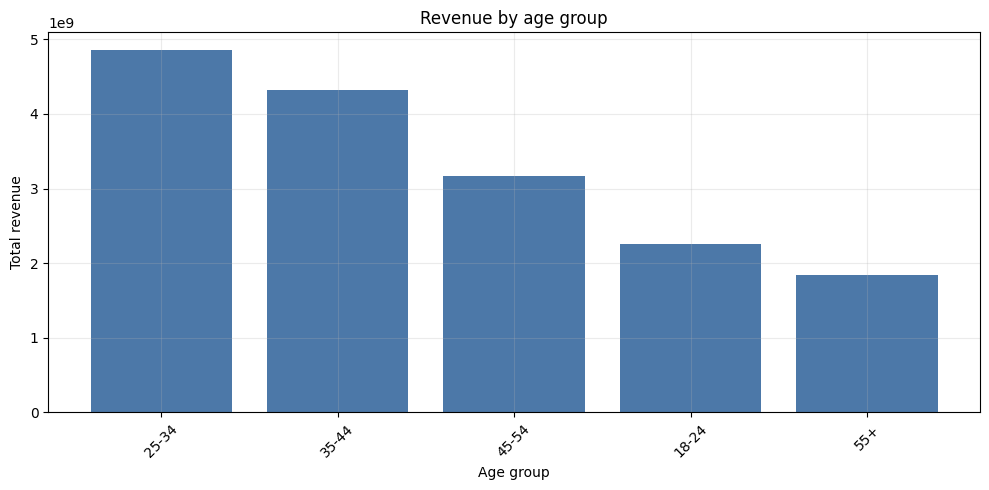

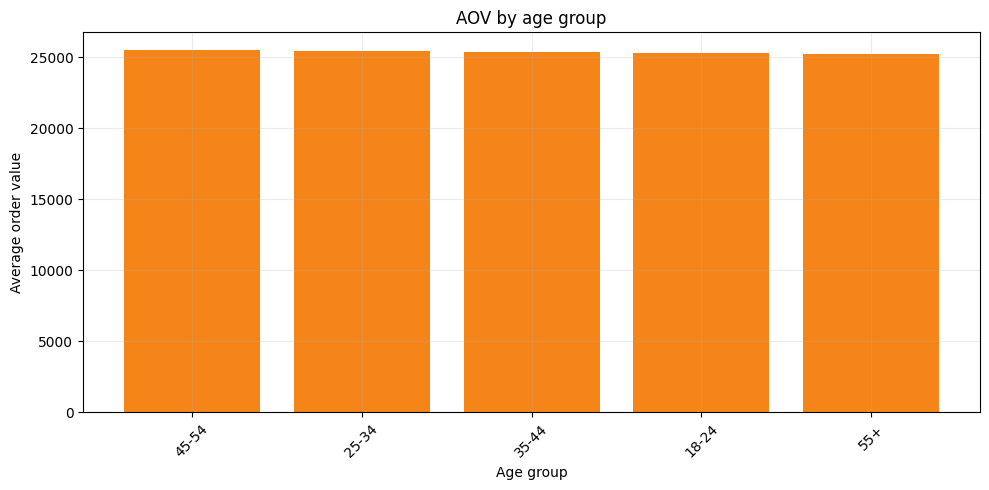

In [7]:
age_summary = pd.DataFrame()

def summarize_by_group(df, group_col):
    if df.empty or group_col not in df.columns:
        return pd.DataFrame()
    summary = df.groupby(group_col).agg(
        customers=("customer_id", "nunique"),
        orders=("order_id", "nunique"),
        total_revenue=("revenue", "sum"),
        median_order_value=("revenue", "median"),
        returned_orders=("is_returned_order", "sum"),
        refund_amount=("refund_amount", "sum"),
    ).reset_index()
    summary["revenue_share"] = summary["total_revenue"] / summary["total_revenue"].sum() if summary["total_revenue"].sum() != 0 else np.nan
    summary["avg_revenue_per_customer"] = summary["total_revenue"] / summary["customers"].replace(0, np.nan)
    summary["aov"] = summary["total_revenue"] / summary["orders"].replace(0, np.nan)
    summary["return_rate"] = summary["returned_orders"] / summary["orders"].replace(0, np.nan)
    summary["refund_to_revenue"] = summary["refund_amount"] / summary["total_revenue"].replace(0, np.nan)
    return summary.sort_values("total_revenue", ascending=False)

if not demographic_order.empty and "revenue" in demographic_order.columns and demographic_order["revenue"].notna().any():
    age_summary = summarize_by_group(demographic_order, "age_group")
    display(age_summary)

    fig, ax = plt.subplots(figsize=(10, 5))
    plot_df = age_summary.sort_values("total_revenue", ascending=False)
    ax.bar(plot_df["age_group"].astype(str), plot_df["total_revenue"], color="#4C78A8")
    ax.set_title("Revenue by age group")
    ax.set_xlabel("Age group")
    ax.set_ylabel("Total revenue")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    plot_df = age_summary.sort_values("aov", ascending=False)
    ax.bar(plot_df["age_group"].astype(str), plot_df["aov"], color="#F58518")
    ax.set_title("AOV by age group")
    ax.set_xlabel("Age group")
    ax.set_ylabel("Average order value")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()
else:
    display_warning("Revenue and AOV by age group skipped because revenue is unavailable.")

## 8. Revenue and AOV by gender

Revenue and order value metrics are summarized by gender. Small or unknown groups should be interpreted cautiously.

,gender_group,customers,orders,total_revenue,median_order_value,returned_orders,refund_amount,revenue_share,avg_revenue_per_customer,aov,return_rate,refund_to_revenue
0,Female,44196,317013,"8,043,710,615.6900","18,233.6800",17694,"249,183,514.9700",0.4896,"182,000.8737","25,373.4409",0.0558,0.0310
1,Male,42481,305013,"7,748,942,723.4800","18,303.5000",16953,"240,288,029.4300",0.4716,"182,409.6119","25,405.2867",0.0556,0.0310
2,Non-binary,3569,24919,"637,823,246.3600","18,348.4200",1415,"21,188,775.1900",0.0388,"178,712.0332","25,595.8604",0.0568,0.0332


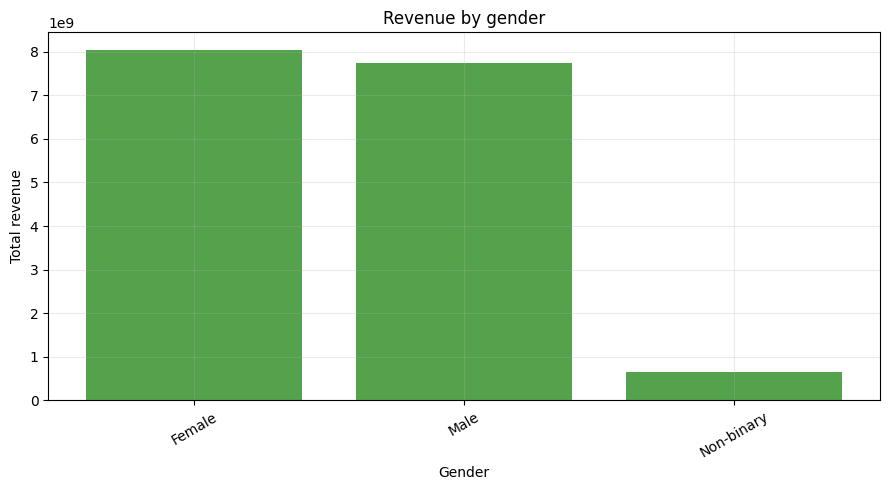

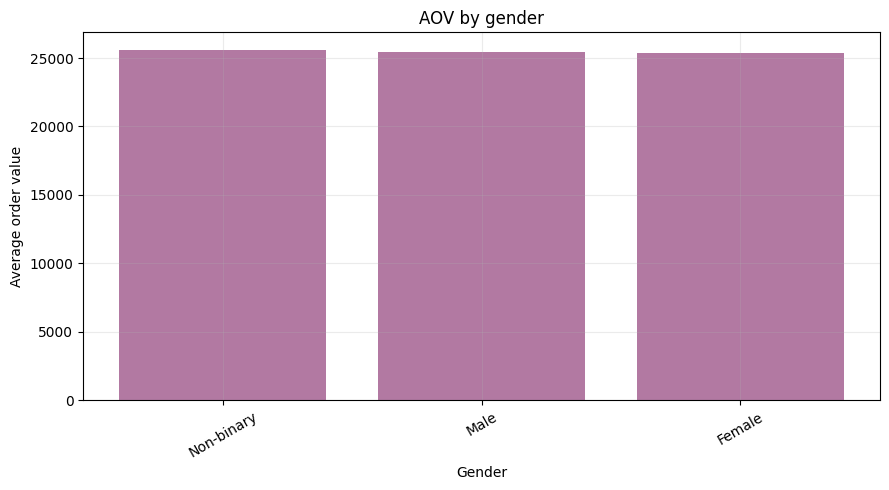

In [8]:
gender_summary = pd.DataFrame()

if not demographic_order.empty and "revenue" in demographic_order.columns and demographic_order["revenue"].notna().any():
    gender_summary = summarize_by_group(demographic_order, "gender_group")
    display(gender_summary)

    fig, ax = plt.subplots(figsize=(9, 5))
    plot_df = gender_summary.sort_values("total_revenue", ascending=False)
    ax.bar(plot_df["gender_group"].astype(str), plot_df["total_revenue"], color="#54A24B")
    ax.set_title("Revenue by gender")
    ax.set_xlabel("Gender")
    ax.set_ylabel("Total revenue")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 5))
    plot_df = gender_summary.sort_values("aov", ascending=False)
    ax.bar(plot_df["gender_group"].astype(str), plot_df["aov"], color="#B279A2")
    ax.set_title("AOV by gender")
    ax.set_xlabel("Gender")
    ax.set_ylabel("Average order value")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()
else:
    display_warning("Revenue and AOV by gender skipped because revenue is unavailable.")

## 9. Return rate by gender and age group

Return rate uses the best available definition. In this notebook it is calculated as returned orders divided by total orders when returns can be matched to orders.

Return-rate definition used: returned orders / total orders


,gender_group,orders,returned_orders,return_rate,refund_to_revenue
2,Non-binary,24919,1415,0.0568,0.0332
0,Female,317013,17694,0.0558,0.0310
1,Male,305013,16953,0.0556,0.0310


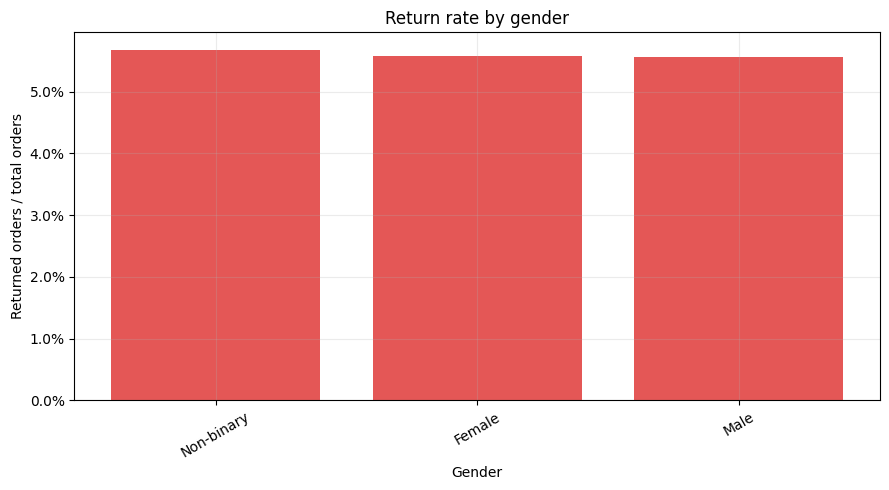

,age_group,orders,returned_orders,return_rate,refund_to_revenue
3,45-54,124138,6997,0.0564,0.0311
2,35-44,170368,9581,0.0562,0.0319
1,25-34,190622,10596,0.0556,0.0309
0,18-24,89057,4937,0.0554,0.0305
4,55+,72760,3951,0.0543,0.0303


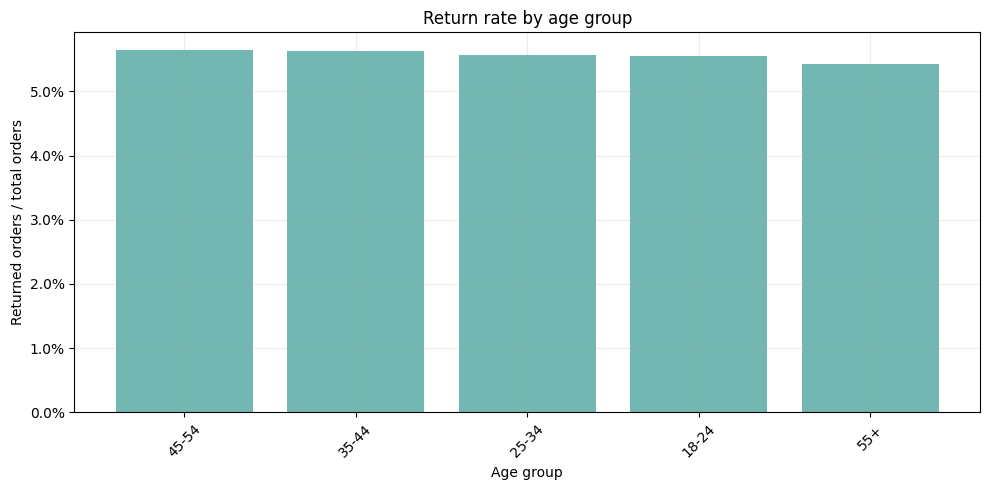

,age_group,gender_group,customers,orders,returned_orders,return_rate
8,35-44,Non-binary,935,6515,407,0.0625
2,18-24,Non-binary,494,3290,200,0.0608
9,45-54,Female,8414,60363,3436,0.0569
7,35-44,Male,11212,80639,4529,0.0562
10,45-54,Male,8082,58781,3298,0.0561
6,35-44,Female,11495,83214,4645,0.0558
4,25-34,Male,12627,90100,5023,0.0557
3,25-34,Female,13142,93368,5183,0.0555
0,18-24,Female,6241,44773,2483,0.0555
12,55+,Female,4904,35295,1947,0.0552


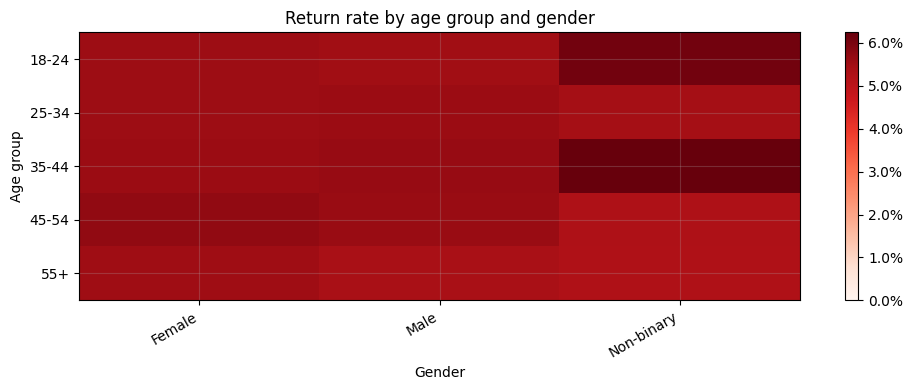

In [9]:
age_gender_return = pd.DataFrame()

if not demographic_order.empty and "is_returned_order" in demographic_order.columns:
    print(f"Return-rate definition used: {return_rate_definition}")

    if not gender_summary.empty:
        display(gender_summary[["gender_group", "orders", "returned_orders", "return_rate", "refund_to_revenue"]].sort_values("return_rate", ascending=False))
        fig, ax = plt.subplots(figsize=(9, 5))
        plot_df = gender_summary.sort_values("return_rate", ascending=False)
        ax.bar(plot_df["gender_group"].astype(str), plot_df["return_rate"], color="#E45756")
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        ax.set_title("Return rate by gender")
        ax.set_xlabel("Gender")
        ax.set_ylabel("Returned orders / total orders")
        ax.tick_params(axis="x", rotation=30)
        plt.tight_layout()
        plt.show()

    if not age_summary.empty:
        display(age_summary[["age_group", "orders", "returned_orders", "return_rate", "refund_to_revenue"]].sort_values("return_rate", ascending=False))
        fig, ax = plt.subplots(figsize=(10, 5))
        plot_df = age_summary.sort_values("return_rate", ascending=False)
        ax.bar(plot_df["age_group"].astype(str), plot_df["return_rate"], color="#72B7B2")
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        ax.set_title("Return rate by age group")
        ax.set_xlabel("Age group")
        ax.set_ylabel("Returned orders / total orders")
        ax.tick_params(axis="x", rotation=45)
        plt.tight_layout()
        plt.show()

    age_gender_return = demographic_order.groupby(["age_group", "gender_group"]).agg(
        customers=("customer_id", "nunique"),
        orders=("order_id", "nunique"),
        returned_orders=("is_returned_order", "sum"),
    ).reset_index()
    age_gender_return["return_rate"] = age_gender_return["returned_orders"] / age_gender_return["orders"].replace(0, np.nan)
    display(age_gender_return.sort_values("return_rate", ascending=False).head(30))

    heat = age_gender_return.pivot(index="age_group", columns="gender_group", values="return_rate")
    if heat.shape[0] >= 2 and heat.shape[1] >= 2:
        fig, ax = plt.subplots(figsize=(10, max(4, heat.shape[0] * 0.55)))
        image = ax.imshow(heat.values, aspect="auto", cmap="Reds", vmin=0, vmax=np.nanmax(heat.values))
        ax.set_title("Return rate by age group and gender")
        ax.set_xlabel("Gender")
        ax.set_ylabel("Age group")
        ax.set_xticks(np.arange(len(heat.columns)))
        ax.set_xticklabels([str(x) for x in heat.columns], rotation=30, ha="right")
        ax.set_yticks(np.arange(len(heat.index)))
        ax.set_yticklabels([str(x) for x in heat.index])
        cbar = fig.colorbar(image, ax=ax)
        cbar.ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        plt.tight_layout()
        plt.show()
else:
    display_warning("Return-rate analysis skipped because return indicators are unavailable.")

## 10. Combined demographic behavior matrix

Age group and gender are combined to identify groups with strong revenue, high AOV, and return-risk differences. Small groups are flagged to avoid over-interpreting sparse segments.

,age_group,gender_group,customers,orders,revenue,median_order_value,returned_orders,refund_amount,aov,return_rate,refund_to_revenue,repeat_order_count,small_sample_flag
3,25-34,Female,13142,93368,"2,370,067,517.0600","18,190.6300",5183,"73,073,492.7300","25,384.1521",0.0555,0.0308,80226,False
4,25-34,Male,12627,90100,"2,299,124,941.9900","18,368.7000",5023,"71,365,080.4700","25,517.4799",0.0557,0.0310,77473,False
6,35-44,Female,11495,83214,"2,109,421,059.7000","18,210.1800",4645,"66,257,057.2800","25,349.3530",0.0558,0.0314,71719,False
7,35-44,Male,11212,80639,"2,045,612,323.8700","18,176.6400",4529,"64,800,887.3200","25,367.5309",0.0562,0.0317,69427,False
9,45-54,Female,8414,60363,"1,537,463,915.6000","18,382.6900",3436,"48,321,082.1600","25,470.3033",0.0569,0.0314,51949,False
10,45-54,Male,8082,58781,"1,497,436,951.8700","18,515.4500",3298,"46,325,418.6400","25,474.8465",0.0561,0.0309,50699,False
0,18-24,Female,6241,44773,"1,138,967,401.5300","18,232.1200",2483,"34,925,069.5700","25,438.7109",0.0555,0.0307,38532,False
1,18-24,Male,5864,40994,"1,032,560,921.9200","18,268.3200",2254,"31,139,597.4500","25,188.0988",0.0550,0.0302,35130,False
12,55+,Female,4904,35295,"887,790,721.8000","18,121.5500",1947,"26,606,813.2300","25,153.4416",0.0552,0.0300,30391,False
13,55+,Male,4696,34499,"874,207,583.8300","18,084.1600",1849,"26,657,045.5500","25,340.0848",0.0536,0.0305,29803,False


High revenue and high return risk:


,age_group,gender_group,customers,orders,revenue,median_order_value,returned_orders,refund_amount,aov,return_rate,refund_to_revenue,repeat_order_count,small_sample_flag
3,25-34,Female,13142,93368,"2,370,067,517.0600","18,190.6300",5183,"73,073,492.7300","25,384.1521",0.0555,0.0308,80226,False
4,25-34,Male,12627,90100,"2,299,124,941.9900","18,368.7000",5023,"71,365,080.4700","25,517.4799",0.0557,0.0310,77473,False
6,35-44,Female,11495,83214,"2,109,421,059.7000","18,210.1800",4645,"66,257,057.2800","25,349.3530",0.0558,0.0314,71719,False
7,35-44,Male,11212,80639,"2,045,612,323.8700","18,176.6400",4529,"64,800,887.3200","25,367.5309",0.0562,0.0317,69427,False
9,45-54,Female,8414,60363,"1,537,463,915.6000","18,382.6900",3436,"48,321,082.1600","25,470.3033",0.0569,0.0314,51949,False
10,45-54,Male,8082,58781,"1,497,436,951.8700","18,515.4500",3298,"46,325,418.6400","25,474.8465",0.0561,0.0309,50699,False


High revenue and low return risk:


,age_group,gender_group,customers,orders,revenue,median_order_value,returned_orders,refund_amount,aov,return_rate,refund_to_revenue,repeat_order_count,small_sample_flag
0,18-24,Female,6241,44773,"1,138,967,401.5300","18,232.1200",2483,"34,925,069.5700","25,438.7109",0.0555,0.0307,38532,False
1,18-24,Male,5864,40994,"1,032,560,921.9200","18,268.3200",2254,"31,139,597.4500","25,188.0988",0.0550,0.0302,35130,False


High AOV and low return risk:


,age_group,gender_group,customers,orders,revenue,median_order_value,returned_orders,refund_amount,aov,return_rate,refund_to_revenue,repeat_order_count,small_sample_flag
11,45-54,Non-binary,697,4994,"128,769,151.1900","18,500.7450",263,"3,693,903.4300","25,784.7720",0.0527,0.0287,4297,False
14,55+,Non-binary,410,2966,"75,524,139.7100","17,880.9800",155,"2,471,514.7200","25,463.2973",0.0523,0.0327,2556,True
0,18-24,Female,6241,44773,"1,138,967,401.5300","18,232.1200",2483,"34,925,069.5700","25,438.7109",0.0555,0.0307,38532,False


Low revenue and high return risk:


,age_group,gender_group,customers,orders,revenue,median_order_value,returned_orders,refund_amount,aov,return_rate,refund_to_revenue,repeat_order_count,small_sample_flag
8,35-44,Non-binary,935,6515,"168,199,537.3900","18,506.1900",407,"6,667,742.1500","25,817.2736",0.0625,0.0396,5580,False
2,18-24,Non-binary,494,3290,"84,096,420.9700","18,317.5500",200,"2,700,950.4800","25,561.2222",0.0608,0.0321,2796,True


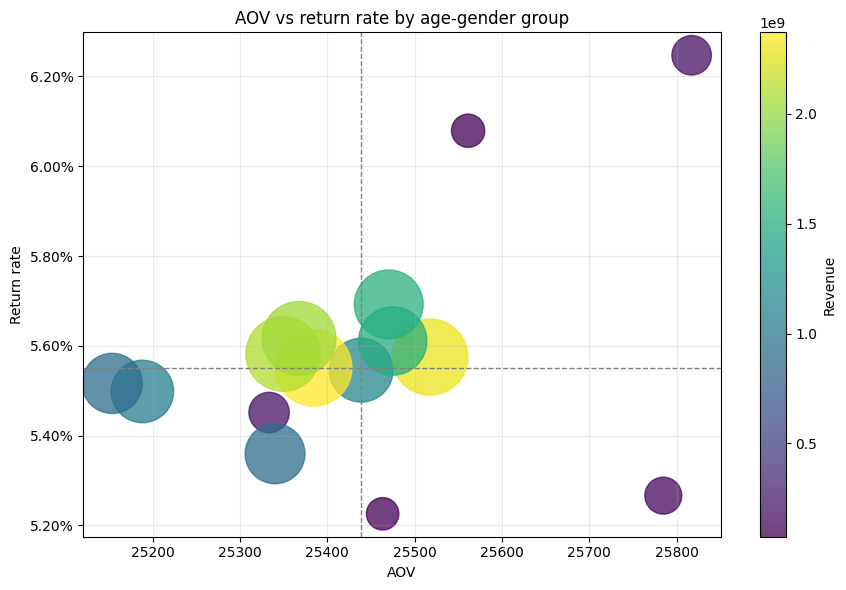

In [10]:
behavior_matrix = pd.DataFrame()
strong_revenue_high_return = pd.DataFrame()
strong_revenue_low_return = pd.DataFrame()
high_aov_low_return = pd.DataFrame()
low_revenue_high_return = pd.DataFrame()

if not demographic_order.empty:
    behavior_matrix = demographic_order.groupby(["age_group", "gender_group"]).agg(
        customers=("customer_id", "nunique"),
        orders=("order_id", "nunique"),
        revenue=("revenue", "sum"),
        median_order_value=("revenue", "median"),
        returned_orders=("is_returned_order", "sum"),
        refund_amount=("refund_amount", "sum"),
    ).reset_index()
    behavior_matrix["aov"] = behavior_matrix["revenue"] / behavior_matrix["orders"].replace(0, np.nan)
    behavior_matrix["return_rate"] = behavior_matrix["returned_orders"] / behavior_matrix["orders"].replace(0, np.nan)
    behavior_matrix["refund_to_revenue"] = behavior_matrix["refund_amount"] / behavior_matrix["revenue"].replace(0, np.nan)

    repeat_counts = demographic_order.sort_values(["customer_id", "order_date", "order_id"]).copy()
    repeat_counts["order_sequence"] = repeat_counts.groupby("customer_id").cumcount() + 1
    repeat_by_group = repeat_counts.groupby(["age_group", "gender_group"])["order_sequence"].apply(lambda s: (s > 1).sum()).rename("repeat_order_count").reset_index()
    behavior_matrix = behavior_matrix.merge(repeat_by_group, on=["age_group", "gender_group"], how="left")
    behavior_matrix["small_sample_flag"] = behavior_matrix["orders"] < max(30, behavior_matrix["orders"].median() * 0.1)

    display(behavior_matrix.sort_values("revenue", ascending=False))

    revenue_threshold = behavior_matrix["revenue"].median()
    aov_threshold = behavior_matrix["aov"].median()
    return_threshold = behavior_matrix["return_rate"].median()
    strong_revenue_high_return = behavior_matrix[(behavior_matrix["revenue"] >= revenue_threshold) & (behavior_matrix["return_rate"] >= return_threshold)].sort_values("revenue", ascending=False)
    strong_revenue_low_return = behavior_matrix[(behavior_matrix["revenue"] >= revenue_threshold) & (behavior_matrix["return_rate"] < return_threshold)].sort_values("revenue", ascending=False)
    high_aov_low_return = behavior_matrix[(behavior_matrix["aov"] >= aov_threshold) & (behavior_matrix["return_rate"] < return_threshold)].sort_values("aov", ascending=False)
    low_revenue_high_return = behavior_matrix[(behavior_matrix["revenue"] < revenue_threshold) & (behavior_matrix["return_rate"] >= return_threshold)].sort_values("return_rate", ascending=False)

    print("High revenue and high return risk:")
    display(strong_revenue_high_return.head(10))
    print("High revenue and low return risk:")
    display(strong_revenue_low_return.head(10))
    print("High AOV and low return risk:")
    display(high_aov_low_return.head(10))
    print("Low revenue and high return risk:")
    display(low_revenue_high_return.head(10))

    fig, ax = plt.subplots(figsize=(9, 6))
    scatter = ax.scatter(
        behavior_matrix["aov"],
        behavior_matrix["return_rate"],
        s=np.sqrt(behavior_matrix["orders"].clip(lower=1)) * 10,
        alpha=0.75,
        c=behavior_matrix["revenue"],
        cmap="viridis",
    )
    ax.axhline(return_threshold, color="gray", linestyle="--", linewidth=1)
    ax.axvline(aov_threshold, color="gray", linestyle="--", linewidth=1)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_title("AOV vs return rate by age-gender group")
    ax.set_xlabel("AOV")
    ax.set_ylabel("Return rate")
    fig.colorbar(scatter, ax=ax, label="Revenue")
    plt.tight_layout()
    plt.show()
else:
    display_warning("Combined demographic behavior matrix skipped because demographic order data is unavailable.")

## 11. Key observations and warnings

The final summary reports top age and gender groups, return-risk groups, and data quality warnings. These are descriptive signals and should not be interpreted as demographic causes of behavior.

In [11]:
print("Concise insight summary")
print("=" * 80)

def top_label(df, label_col, metric_col, n=3, fmt="{value:,.2f}"):
    if df is None or df.empty or metric_col not in df.columns:
        return "not available"
    rows = df.sort_values(metric_col, ascending=False).head(n)
    return "; ".join(f"{getattr(row, label_col)} ({fmt.format(value=getattr(row, metric_col))})" for row in rows.itertuples(index=False))

if not age_summary.empty:
    print("Age groups with highest purchase volume: " + top_label(age_summary, "age_group", "orders", fmt="{value:,.0f}") + ".")
    print("Age groups with highest revenue: " + top_label(age_summary, "age_group", "total_revenue", fmt="{value:,.2f}") + ".")
    print("Age groups with highest AOV: " + top_label(age_summary, "age_group", "aov", fmt="{value:,.2f}") + ".")
else:
    print("Age-group revenue/AOV summary: not available.")

if not gender_summary.empty:
    print("Gender groups with highest revenue: " + top_label(gender_summary, "gender_group", "total_revenue", fmt="{value:,.2f}") + ".")
    print("Gender groups with highest AOV: " + top_label(gender_summary, "gender_group", "aov", fmt="{value:,.2f}") + ".")
else:
    print("Gender revenue/AOV summary: not available.")

if not age_summary.empty:
    print("Age groups with highest return rate: " + top_label(age_summary, "age_group", "return_rate", fmt="{value:.2%}") + ".")
if not gender_summary.empty:
    print("Gender groups with highest return rate: " + top_label(gender_summary, "gender_group", "return_rate", fmt="{value:.2%}") + ".")

if not strong_revenue_high_return.empty:
    text = "; ".join(
        f"{row.age_group}/{row.gender_group} (revenue {row.revenue:,.2f}, return rate {row.return_rate:.2%})"
        for row in strong_revenue_high_return.head(5).itertuples(index=False)
    )
    print(f"Groups with strong revenue but high return risk: {text}.")
else:
    print("Groups with strong revenue but high return risk: not identified from the available data.")

if not strong_revenue_low_return.empty:
    text = "; ".join(
        f"{row.age_group}/{row.gender_group} (revenue {row.revenue:,.2f}, return rate {row.return_rate:.2%})"
        for row in strong_revenue_low_return.head(5).itertuples(index=False)
    )
    print(f"Groups with strong revenue and low return risk: {text}.")
else:
    print("Groups with strong revenue and low return risk: not identified from the available data.")

quality_warnings = []
if demographic_order.empty:
    quality_warnings.append("demographic order dataset could not be built")
if age_group_col is None and age_col is None and birth_date_col is None and birth_year_col is None:
    quality_warnings.append("age fields unavailable")
if gender_col is None:
    quality_warnings.append("gender field unavailable")
if revenue_source.get("source") is None:
    quality_warnings.append("revenue unavailable or not inferable")
if returns is None or return_order_col is None:
    quality_warnings.append("returns unavailable or not matchable")
if not pd.isna(suspicious_age_count) and suspicious_age_count > 0:
    quality_warnings.append(f"{int(suspicious_age_count):,} suspicious age values flagged")
if not demographic_order.empty:
    unknown_age_orders = int((demographic_order["age_group"].astype(str).str.lower() == "unknown").sum())
    unknown_gender_orders = int((demographic_order["gender_group"].astype(str).str.lower() == "unknown").sum())
    if unknown_age_orders > 0:
        quality_warnings.append(f"{unknown_age_orders:,} orders with unknown age group")
    if unknown_gender_orders > 0:
        quality_warnings.append(f"{unknown_gender_orders:,} orders with unknown gender")
    if (demographic_order["revenue"] < 0).any():
        quality_warnings.append(f"{int((demographic_order['revenue'] < 0).sum()):,} orders with negative revenue")
    if (demographic_order["revenue"] == 0).any():
        quality_warnings.append(f"{int((demographic_order['revenue'] == 0).sum()):,} orders with zero revenue")

print("Return-rate definition: " + return_rate_definition + ".")
print("Data quality warnings: " + ("; ".join(quality_warnings) if quality_warnings else "none material for the detected fields") + ".")
print("Interpretation warning: demographic differences are exploratory associations, not evidence that age or gender causes revenue, AOV, or returns.")

Concise insight summary
Age groups with highest purchase volume: 25-34 (190,622); 35-44 (170,368); 45-54 (124,138).
Age groups with highest revenue: 25-34 (4,850,426,456.15); 35-44 (4,323,232,920.96); 45-54 (3,163,670,018.66).
Age groups with highest AOV: 45-54 (25,485.11); 25-34 (25,445.26); 35-44 (25,375.85).
Gender groups with highest revenue: Female (8,043,710,615.69); Male (7,748,942,723.48); Non-binary (637,823,246.36).
Gender groups with highest AOV: Non-binary (25,595.86); Male (25,405.29); Female (25,373.44).
Age groups with highest return rate: 45-54 (5.64%); 35-44 (5.62%); 25-34 (5.56%).
Gender groups with highest return rate: Non-binary (5.68%); Female (5.58%); Male (5.56%).
Groups with strong revenue but high return risk: 25-34/Female (revenue 2,370,067,517.06, return rate 5.55%); 25-34/Male (revenue 2,299,124,941.99, return rate 5.57%); 35-44/Female (revenue 2,109,421,059.70, return rate 5.58%); 35-44/Male (revenue 2,045,612,323.87, return rate 5.62%); 45-54/Female (reven

Return-rate definition: returned orders / total orders.
Data quality warnings: none material for the detected fields.
Interpretation warning: demographic differences are exploratory associations, not evidence that age or gender causes revenue, AOV, or returns.
